In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('TIMING.csv')

In [3]:
rot_fit_time = float(df[df['ID'] == 'rot_train___128_1e-05_0.5'].iloc[0]['time'])
rot_explain_time = float(df[df['ID'] == 'rot_explanation'].iloc[0]['time'])
rot_combined = float(df[df['ID'] == 'rot_combined'].iloc[0]['time'])

In [4]:
df_embedding = df[df['ID'] == 'embedding_generation']
df_shap = df[df['ID'] == 'shap']
df_shap=df_shap.sort_values(by='time')
df_ig = df[df['ID'] == 'ig']
df_ig=df_ig.sort_values(by='time')

In [5]:
df_ig['cumm_time'] = df_ig['time'].cumsum()
df_ig['avg_time'] = 1
df_ig['avg_time'] = df_ig['cumm_time'] / df_ig['avg_time'].cumsum()

In [6]:
df_shap['cumm_time'] = df_shap['time'].cumsum()
df_shap['avg_time'] = 1
df_shap['avg_time'] = df_shap['cumm_time'] / df_shap['avg_time'].cumsum()

In [7]:
df_shap['rot_cumm'] = rot_combined
df_shap['rot_cumm'] += np.linspace(0,rot_explain_time, len(df_shap)+1)[1:]
df_shap['rot_avg'] = 1
df_shap['rot_avg'] = df_shap['rot_avg'].cumsum()
df_shap['rot_avg'] = df_shap['rot_cumm'] / df_shap['rot_avg']

In [8]:
df_shap['case_number'] = [i+1 for i in range(len(df_shap))]
df_ig['case_number'] = [i+1 for i in range(len(df_ig))]

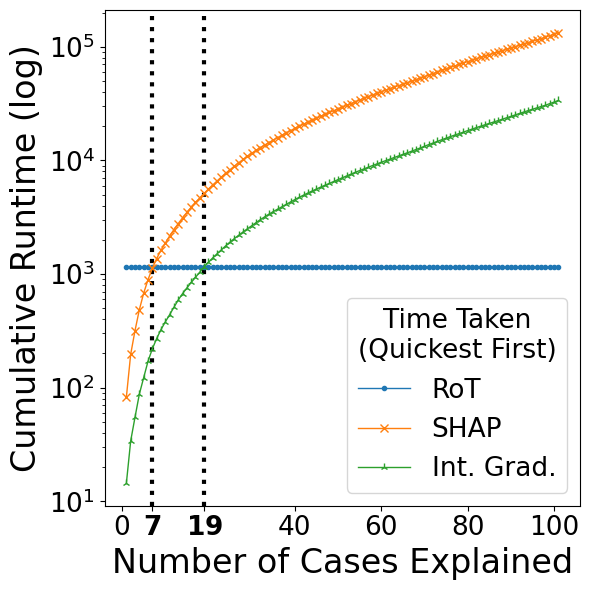

In [9]:
plt.figure(figsize=(6,6))
plt.axvline(7, linestyle=':', color='black', linewidth=3)
plt.axvline(19, linestyle=':', color='black', linewidth=3)
plt.plot(df_shap['case_number'], df_shap['rot_cumm'], label='RoT', marker='.', linewidth=1)
plt.plot(df_shap['case_number'], df_shap['cumm_time'], label='SHAP', marker='x', linewidth=1)
plt.plot(df_ig['case_number'], df_ig['cumm_time'], label='Int. Grad.', marker='2', linewidth=1)
plt.xlabel('Number of Cases Explained', fontsize=24)
plt.ylabel('Cumulative Runtime (log)', fontsize=24)
plt.yscale('log')
# plt.title('RoT vs SHAP: (cumulative) Time to Compute Explanations')
# plt.xticks(list(plt.xticks()[0]) + [7])
plt.xticks([0,7,19,40,60,80,100], labels=['0', '$\mathbf{7}$', '$\mathbf{19}$', '40', '60', '80', '100'], fontsize=19)
plt.yticks(fontsize=19)
plt.legend(fontsize=19, title_fontsize=19, title="   Time Taken   \n(Quickest First)")
plt.tight_layout()
plt.savefig('sorted_runtimes_cumulative.pdf', dpi=300)

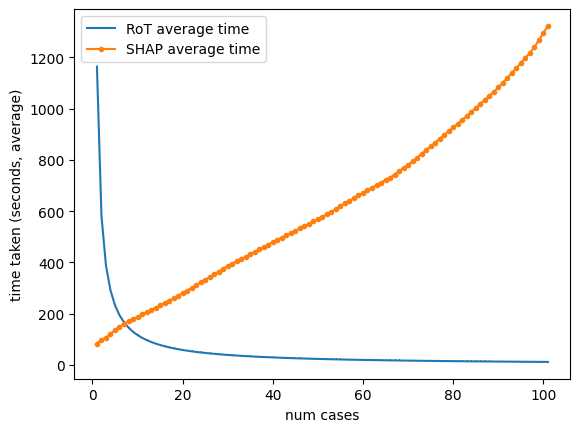

In [10]:
plt.plot(df_shap['case_number'], df_shap['rot_avg'], label='RoT average time', marker=',')
plt.plot(df_shap['case_number'], df_shap['avg_time'], label='SHAP average time', marker='.')
# plt.axhline(np.mean(df_shap['avg_time']), label='SHAP overall average', linestyle=':')
# plt.axhline(df_shap['rot_cumm'].values.tolist()[-1], label='RoT total', linestyle=':')
plt.xlabel('num cases')
plt.ylabel('time taken (seconds, average)')
plt.legend()


In [11]:
rot_times = [rot_explain_time / len(df_shap)] * len(df_shap)
rot_times[0] += rot_combined

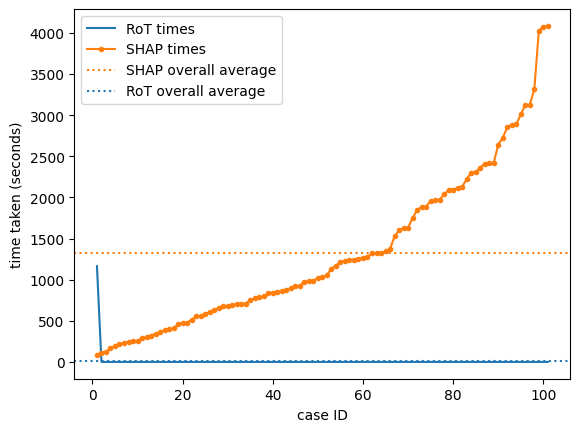

In [12]:
plt.plot(df_shap['case_number'], rot_times, label='RoT times', marker=',')
plt.plot(df_shap['case_number'], sorted(df_shap['time']), label='SHAP times', marker='.')
plt.axhline(np.mean(df_shap['time']), label='SHAP overall average', linestyle=':', color='tab:orange')
plt.axhline(np.mean(rot_times), label='RoT overall average', linestyle=':')

plt.xlabel('case ID')
plt.ylabel('time taken (seconds)')
plt.legend()


In [13]:
np.mean(df_shap['time'])

1322.8709806829395

In [14]:
np.mean(rot_times)

11.52169080535964

In [15]:
np.mean(df_shap['time']) / np.mean(rot_times)

114.8156987573012